JURNAL MODUL 2

In [138]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(720, 720, 3)


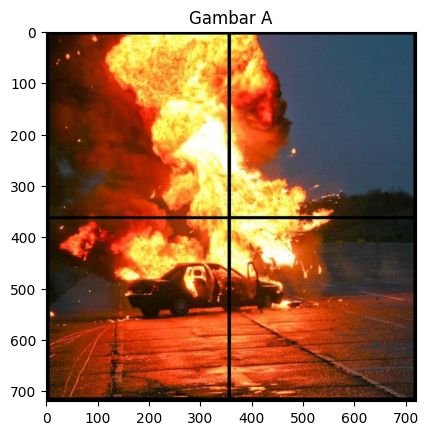

In [139]:
gambarA = plt.imread('Assets/Meledak.png')
plt.imshow(gambarA)
plt.title('Gambar A')
print(gambarA.shape)

(720, 720, 3)


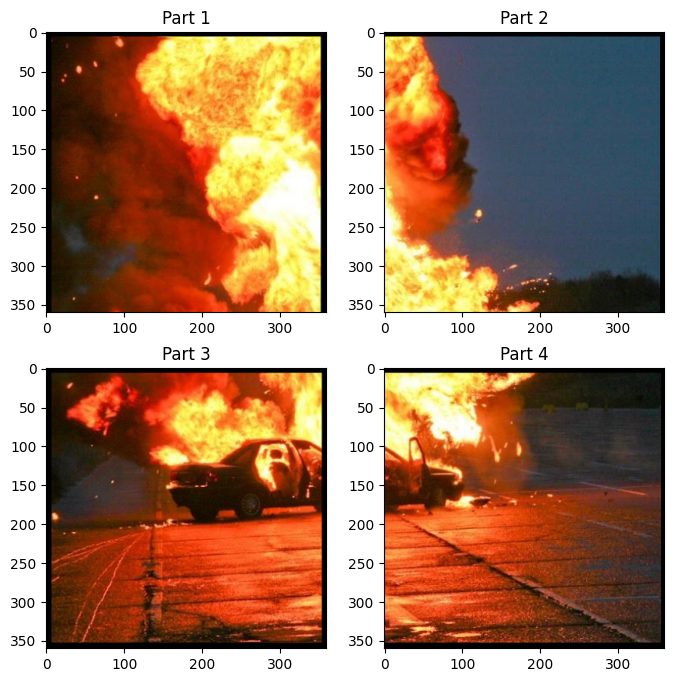

In [140]:
tinggi, lebar, channel = gambarA.shape

tengah_tinggi = tinggi // 2
tengah_lebar = lebar // 2

bagian1 = gambarA[0:tengah_tinggi, 0:tengah_lebar]
bagian2 = gambarA[0:tengah_tinggi, tengah_lebar:lebar]
bagian3 = gambarA[tengah_tinggi:tinggi, 0:tengah_lebar]
bagian4 = gambarA[tengah_tinggi:tinggi, tengah_lebar:lebar]

fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(bagian1)
ax[0,0].set_title('Part 1')
ax[0,1].imshow(bagian2)
ax[0,1].set_title('Part 2')
ax[1,0].imshow(bagian3)
ax[1,0].set_title('Part 3')
ax[1,1].imshow(bagian4)
ax[1,1].set_title('Part 4')

print(gambarA.shape)
plt.show()


(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

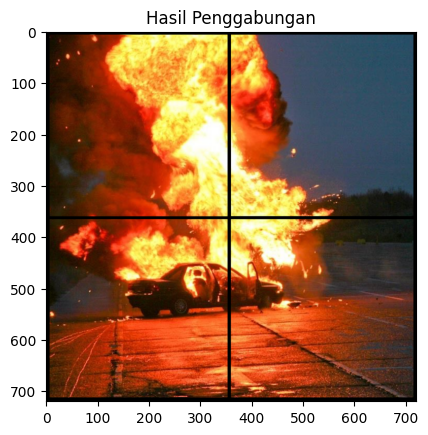

In [141]:
atas = np.hstack((bagian1, bagian2))
bawah = np.hstack((bagian3, bagian4))

gabung = np.vstack((atas, bawah))

plt.imshow(gabung)
plt.title("Hasil Penggabungan")
plt.axis('on')

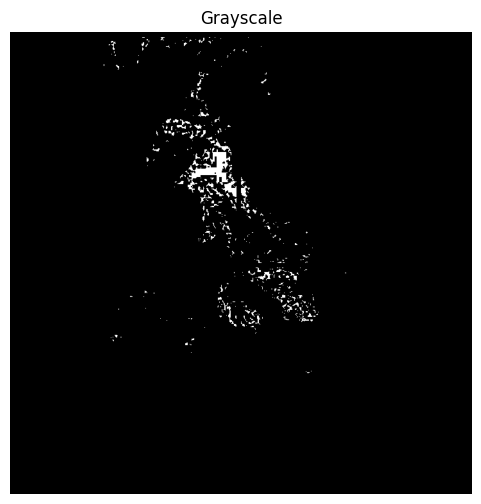

In [149]:
gabung = gabung.astype(np.uint8)

grayscale = cv2.cvtColor(gabung, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(grayscale, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

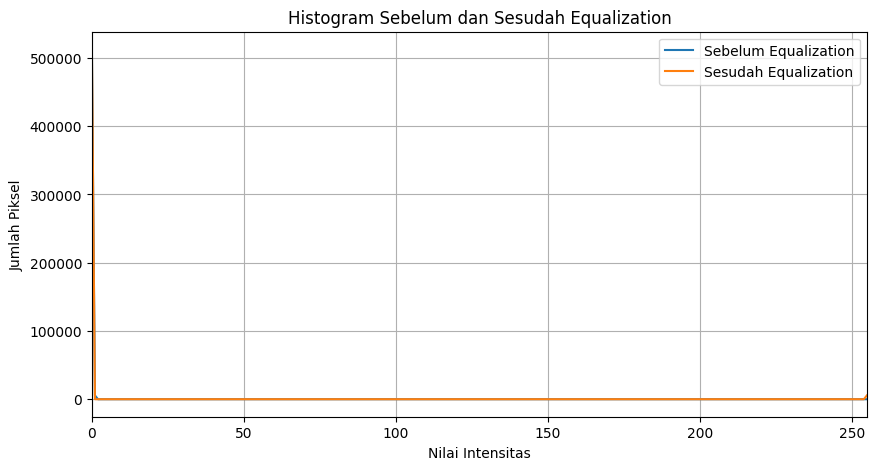

In [143]:
def hitung_histogram(image):

    hist = [0] * 256

    for baris in image:
        for px in baris:

            hist[int(px)] += 1

    return hist


hist_sebelum = hitung_histogram(grayscale)

equal = cv2.equalizeHist(grayscale)

hist_sesudah = hitung_histogram(equal)

plt.figure(figsize=(10,5))

plt.plot(hist_sebelum, label='Sebelum Equalization')
plt.plot(hist_sesudah, label='Sesudah Equalization')

plt.title('Histogram Sebelum dan Sesudah Equalization')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')

plt.xlim([0,255])
plt.legend()
plt.grid(True)

plt.show()

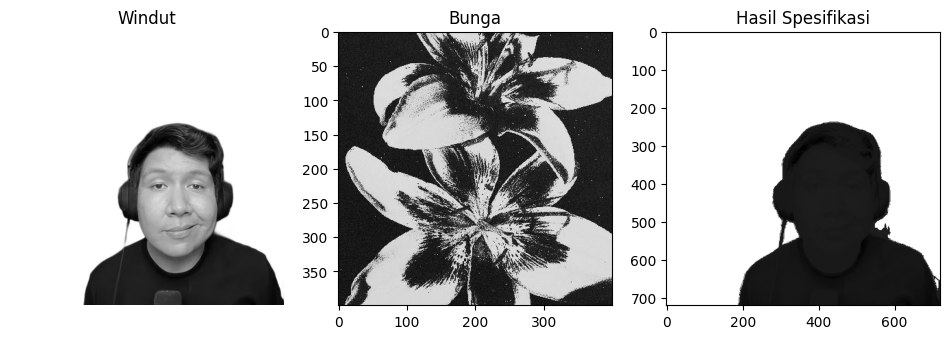

In [144]:

windut = cv2.imread('Assets/Windut.png', 0)
bunga = cv2.imread('Assets/Bunga.png', 0)

def histogram_specification(source_image, target_image):

    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            pixel = source_image[i, j]
            hist_source[pixel] += 1

    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            pixel = target_image[i, j]
            hist_target[pixel] += 1

    cdf_source = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_source[0] = hist_source[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_source[i] = cdf_source[i-1] + hist_source[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_source = cdf_source / cdf_source[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih = np.abs(cdf_source[i] - cdf_target)
        map_hist[i] = np.argmin(selisih)

    height, width = source_image.shape

    result = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):

            result[i, j] = map_hist[source_image[i, j]]

    return result

hasil = histogram_specification(windut, bunga)

# Menampilkan gambar
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(windut, cmap='gray')
plt.title("Windut")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bunga, cmap='gray')
plt.title("Bunga")
plt.axis('on')

plt.subplot(1,3,3)
plt.imshow(hasil, cmap='gray')
plt.title("Hasil Spesifikasi")
plt.axis('on')

plt.show()

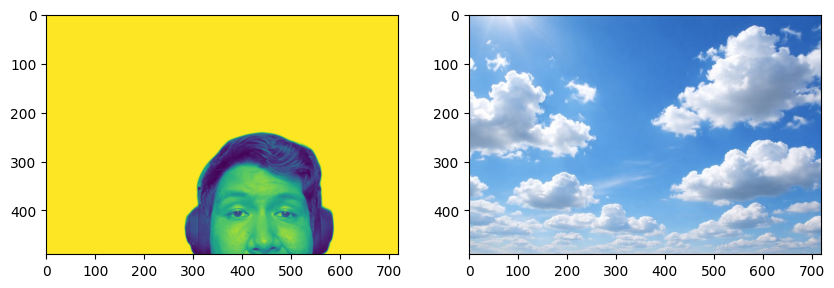

In [157]:
Langit = cv2.imread('Assets/Langit.png')
Langit = cv2.cvtColor(Langit, cv2.COLOR_BGR2RGB)

tinggi1, lebar1 = hasil.shape
tinggi2, lebar2, c2 = Langit.shape

tinggi_baru = min(tinggi1, tinggi2)
lebar_baru = min(lebar1, lebar2)

crop1 = windut[0:tinggi_baru, 0:lebar_baru]
crop2 = Langit[0:tinggi_baru, 0:lebar_baru]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(crop1)

plt.subplot(1,2,2)
plt.imshow(crop2)

plt.show()